<a href="https://colab.research.google.com/github/MouseLand/cellpose/blob/main/notebooks/run_Cellpose-SAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Run Cellpose-SAM

Adapted from Marius Pachitariu, Michael Rariden, Carsen Stringer and the notebook by Pradeep Rajasekhar, inspired by the [ZeroCostDL4Mic notebook series](https://github.com/HenriquesLab/ZeroCostDL4Mic/wiki)

[paper](https://www.biorxiv.org/content/10.1101/2025.04.28.651001v1) | [code](https://github.com/MouseLand/cellpose)

In [1]:
# Check GPU and instantiate model - will download weights.
import numpy as np
from cellpose import models, core, io, plot, utils
from cellpose_functions import *
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
import cv2 as cv 
import tifffile as tf
%matplotlib inline
from natsort import natsorted

#Check if GPU access


## Check if the GPU is correctly loaded
Also now can choose model in cpsam 4.2


In [2]:
pretrained_model = "cpsam_v2"
pretrained_models =["cpsam_v2", "cpsam", "cpdino", "cpdino-vitb"]

def load_model(pretrained_model="cpsam_v2", gpu=True):
    """
    Loads a cellpose model, uses cp_sam by default but can specify any model
    Parameters:
          pretrained_model (None or str): the name of the pretrained model specified, by default assumes cpsam
          gpu (bool, optional): specify whether or not to use gpu, true by default

    Returns:
          model (Cellpose.model object): the model loaded
    """
    io.logger_setup() #run this to get printing of progress
    if gpu == True:
        if core.use_gpu() == False:
            raise ImportError("No GPU access, change your runtime")

    model = models.CellposeModel(pretrained_model=pretrained_model, gpu=True)
    return model

load_model()

[GUI INFO] : WRITING LOG OUTPUT TO /home/mattiazzilab/.cellpose/run.log

cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.6.0+cu124
2026-06-16 12:03:37,821 [io INFO] WRITING LOG OUTPUT TO /home/mattiazzilab/.cellpose/run.log
2026-06-16 12:03:37,821 [io INFO] 
cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.6.0+cu124
2026-06-16 12:03:37,893 [core INFO] ** TORCH CUDA version installed and working. **
2026-06-16 12:03:37,893 [core INFO] ** TORCH CUDA version installed and working. **
2026-06-16 12:03:37,893 [core INFO] >>>> using GPU (CUDA)
2026-06-16 12:03:38,836 [models INFO] >>>> loading model /home/mattiazzilab/.cellpose/models/cpsam_v2


## Set the input directory with your images:

In [3]:
#Inputs
dirfolder = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/Reworking_MitoSegmentation/MitoSegSubset" # "/mnt/bigdisk1/AllieSpangaro/IF_HAP1_October2019/max_projections"
#dirfolder = ("/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ")


dirfolder = Path(dirfolder)
if not dirfolder.exists():
  raise FileNotFoundError("directory does not exist")

# *** To pick a folder: dirfolder = Path("/path/to/your/folder") ***
dirlist = [p for p in dirfolder.rglob("*") if p.is_dir() and "masks" not in p.name and "flows" not in p.name]
#dirlist = [dir for dir in dirfolder.glob("*")]
display(dirlist)

[PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/Reworking_MitoSegmentation/MitoSegSubset/rep01'),
 PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/Reworking_MitoSegmentation/MitoSegSubset/rep04'),
 PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/Reworking_MitoSegmentation/MitoSegSubset/rep02'),
 PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/Reworking_MitoSegmentation/MitoSegSubset/rep06'),
 PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/Reworking_MitoSegmentation/MitoSegSubset/rep05'),
 PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/Reworking_MitoSegmentation/MitoSegSubset/rep07'),
 PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/Reworking_MitoSegmentation/MitoSegSubset/rep03')]

In [4]:
# *** To view files: change to your image extension ***
image_ext = ".tif"
#nchannels = 4

# files = natsorted(
#     [
#         f
#         for f in dirfolder.glob("*" + image_ext)
#         if "_masks" not in f.name and "_flows" not in f.name
#     ]
# )

# if len(files) == 0:
#     raise FileNotFoundError(
#         "no image files found, did you specify the correct folder and extension?"
#     )
# else:
#     print(f"{len(files)} images in folder:")

# for f in files:
#     print(f.name)

# Recursively run through a folder of image files one-by-one

In [5]:
def run_cellpose_on_folder_list(dirlist, pretrained_model="cpsam_v2", v2=True, test_all_models=False, pretrained_models=pretrained_models):
    for dir in dirlist:
        maskdir = dir / "testmasks"
        maskdir.mkdir(exist_ok=True)
        #nchannels = 4
        if dir.name == "for_figs":#the folders that are already done
            continue
        else:
            if dir.name == "20241112_rep04":
                nchannels = 3
            else:
                nchannels = 4
            print("writing to: " + str(maskdir))
            files = load_sorted_directory_list(dir)
            if test_all_models:
                for model in pretrained_models:
                    print(f"Testing model: {model}")
                    save_mask_folder(files,maskdir,v2=v2, pretrained_model=model, show_model_name=True)
            else:
                save_mask_folder(files,maskdir,v2=v2, pretrained_model=pretrained_model)
        
run_cellpose_on_folder_list(dirlist,v2=True, test_all_models=True)


writing to: /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/Reworking_MitoSegmentation/MitoSegSubset/rep01/testmasks
Testing model: cpsam_v2
[GUI INFO] : WRITING LOG OUTPUT TO /home/mattiazzilab/.cellpose/run.log

cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.6.0+cu124
2026-06-16 12:03:42,620 [io INFO] WRITING LOG OUTPUT TO /home/mattiazzilab/.cellpose/run.log
2026-06-16 12:03:42,620 [io INFO] 
cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.6.0+cu124
2026-06-16 12:03:42,621 [core INFO] ** TORCH CUDA version installed and working. **
2026-06-16 12:03:42,621 [core INFO] ** TORCH CUDA version installed and working. **
2026-06-16 12:03:42,621 [core INFO] >>>> using GPU (CUDA)
2026-06-16 12:03:43,471 [models INFO] >>>> loading model /home/mattiazzilab/.cellpose/models/cpsam_v2


100%|██████████| 3/3 [00:06<00:00,  2.17s/it]

Testing model: cpsam
[GUI INFO] : WRITING LOG OUTPUT TO /home/mattiazzilab/.cellpose/run.log

cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.6.0+cu124
2026-06-16 12:03:50,202 [io INFO] WRITING LOG OUTPUT TO /home/mattiazzilab/.cellpose/run.log
2026-06-16 12:03:50,202 [io INFO] 
cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.6.0+cu124
2026-06-16 12:03:50,203 [core INFO] ** TORCH CUDA version installed and working. **
2026-06-16 12:03:50,203 [core INFO] ** TORCH CUDA version installed and working. **
2026-06-16 12:03:50,203 [core INFO] >>>> using GPU (CUDA)


2026-06-16 12:03:51,091 [models INFO] >>>> loading model /home/mattiazzilab/.cellpose/models/cpsam


100%|██████████| 3/3 [00:05<00:00,  1.95s/it]

...

Testing model: cpdino-vitb
[GUI INFO] : WRITING LOG OUTPUT TO /home/mattiazzilab/.cellpose/run.log

cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.6.0+cu124
2026-06-16 12:14:49,068 [io INFO] WRITING LOG OUTPUT TO /home/mattiazzilab/.cellpose/run.log
2026-06-16 12:14:49,068 [io INFO] 
cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.6.0+cu124
2026-06-16 12:14:49,069 [core INFO] ** TORCH CUDA version installed and working. **
2026-06-16 12:14:49,069 [core INFO] ** TORCH CUDA version installed and working. **
2026-06-16 12:14:49,069 [core INFO] >>>> using GPU (CUDA)


2026-06-16 12:14:49,496 [models INFO] >>>> loading model /home/mattiazzilab/.cellpose/models/cpdino-vitb


100%|██████████| 31/31 [00:46<00:00,  1.48s/it]

writing to: /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/Reworking_MitoSegmentation/MitoSegSubset/rep03/testmasks


FileNotFoundError: no image files found, did you specify the correct folder and extension?

[INFO] WRITING LOG OUTPUT TO /home/mattiazzilab/.cellpose/run.log
Note: remember https://pmc.ncbi.nlm.nih.gov/articles/PMC8560386/#sec5 for mitochondria

### set up the correct order for the image filenames - sort by location first, then channel
these functions moved to cellpose_functions


## Run Cellpose-SAM on one image in folder

Here are some of the parameters you can change:

* ***flow_threshold*** is  the  maximum  allowed  error  of  the  flows  for  each  mask.   The  default  is 0.4.
    *  **Increase** this threshold if cellpose is not returning as many masks as you’d expect (or turn off completely with 0.0)
    *   **Decrease** this threshold if cellpose is returning too many ill-shaped masks.

* ***cellprob_threshold*** determines proability that a detected object is a cell.   The  default  is 0.0.
    *   **Decrease** this threshold if cellpose is not returning as many masks as you’d expect or if masks are too small
    *   **Increase** this threshold if cellpose is returning too many masks esp from dull/dim areas.

* ***tile_norm_blocksize*** determines the size of blocks used for normalizing the image. The default is 0, which means the entire image is normalized together.
  You may want to change this to 100-200 pixels if you have very inhomogeneous brightness across your image.



In [8]:
img_files_test = load_sorted_directory_list(dirlist[0])
maskdir = dirlist[0] / "a_testmasks"
maskdir.mkdir(exist_ok=True)

display(img_files_test)
print(maskdir)
files = img_files_test 
#files = sort_files(dir, image_ext)
grouped_files = group_files_by_channel_dict(files)
display(grouped_files)
#print_files(files)
print_grouped_files(grouped_files)
#print(f"\nSet name: {get_image_set_name(grouped_files[0], 1)}")
#print(f"Plate location: {get_location_code(files[0].name)}")

print(f"Number of channels: {get_nchannels(files)}")

[PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250410_rep06/MAX_ch1-r01c02f01.tif'),
 PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250410_rep06/MAX_ch2-r01c02f01.tif'),
 PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250410_rep06/MAX_ch3-r01c02f01.tif'),
 PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250410_rep06/MAX_ch4-r01c02f01.tif'),
 PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250410_rep06/MAX_ch1-r01c02f02.tif'),
 PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250410_rep06/MAX_ch2-r01c02f02.tif'),
 PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250410_rep06/MAX_ch3-r01c02f02.tif'),
 PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative

/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250410_rep06/a_testmasks


{'rep06_r01c02f01': [PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250410_rep06/MAX_ch1-r01c02f01.tif'),
  PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250410_rep06/MAX_ch2-r01c02f01.tif'),
  PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250410_rep06/MAX_ch3-r01c02f01.tif'),
  PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250410_rep06/MAX_ch4-r01c02f01.tif')],
 'rep06_r01c02f02': [PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250410_rep06/MAX_ch1-r01c02f02.tif'),
  PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250410_rep06/MAX_ch2-r01c02f02.tif'),
  PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250410_rep06/MAX_ch3-r01c02f02.tif'),
  PosixPath('/mn


 Group 1 of 3120: rep06_r01c02f01
 MAX_ch1-r01c02f01.tif
 MAX_ch2-r01c02f01.tif
 MAX_ch3-r01c02f01.tif
 MAX_ch4-r01c02f01.tif

 Group 2 of 3120: rep06_r01c02f02
 MAX_ch1-r01c02f02.tif
 MAX_ch2-r01c02f02.tif
 MAX_ch3-r01c02f02.tif
 MAX_ch4-r01c02f02.tif

 Group 3 of 3120: rep06_r01c02f03
 MAX_ch1-r01c02f03.tif
 MAX_ch2-r01c02f03.tif
 MAX_ch3-r01c02f03.tif
 MAX_ch4-r01c02f03.tif

 Group 4 of 3120: rep06_r01c02f04
 MAX_ch1-r01c02f04.tif
 MAX_ch2-r01c02f04.tif
 MAX_ch3-r01c02f04.tif
 MAX_ch4-r01c02f04.tif

 Group 5 of 3120: rep06_r01c02f05
 MAX_ch1-r01c02f05.tif
 MAX_ch2-r01c02f05.tif
 MAX_ch3-r01c02f05.tif
 MAX_ch4-r01c02f05.tif

 Group 6 of 3120: rep06_r01c02f06
 MAX_ch1-r01c02f06.tif
 MAX_ch2-r01c02f06.tif
 MAX_ch3-r01c02f06.tif
 MAX_ch4-r01c02f06.tif

 Group 7 of 3120: rep06_r01c02f07
 MAX_ch1-r01c02f07.tif
 MAX_ch2-r01c02f07.tif
 MAX_ch3-r01c02f07.tif
 MAX_ch4-r01c02f07.tif

 Group 8 of 3120: rep06_r01c02f08
 MAX_ch1-r01c02f08.tif
 MAX_ch2-r01c02f08.tif
 MAX_ch3-r01c02f08.tif
 MAX_ch

### Load in and preprocess the images 
#### For Channel Selection
If you have a fluroescent image with multiple stains, you should choose one channel with a cytoplasm/membrane stain, one channel with a nuclear stain, and set the third channel to None. Choosing multiple channels may produce segmentaiton of all the structures in the image.

In [23]:
def load_image_set_test(single_grouped_files_by_channel, nchannels=None):
    """
    Load an image set given file paths for a single image set; load images from a single element of the list made by the `group_files_by_channel` function
    Parameters:
          single_grouped_files_by_channel (list of Path objects): list of file paths grouped by channel and ordered by platemap location
          nchannels (int or None): the number of channels. Assumes based on length of first element otherwise
    Returns:
          image_set (list of 2D arrays): a list of 2D arrays representing the loaded single-channel grayscale images
    """
    if nchannels == None:
        nchannels = len(single_grouped_files_by_channel)
    # load the images from the channels - skip ch3 at position 2 as DAPI is always the last channel
   
    image_set = []
    for i in range(nchannels):
        image_channel = io.imread(single_grouped_files_by_channel[i])
        image_set.append(image_channel)
    return image_set
def img_preprocessing_test(
    img_set, selected_channels=[1,2,3,4]
):
    """
    Preprocess a grayscale image given an list of single-channel grayscale images with historam equalization, and median filter smoothing and stack the image together
    Parameters:
           img_set (list of 2D arrays): a list of 2D arrays representing grayscale images
    Returns:
          multi_channel_image (3D array): a 3D array containing the preprocessed grayscale images
    """
    from skimage import filters, data, morphology,restoration, exposure

    # ch1,ch2,ch3 = io.imread(files[0]), io.imread(files[1]), io.imread(files[3])
    # channels = [ch1, ch2, ch3]
    img_stack = []
    for chnum in selected_channels:
        # footprint = morphology.disk(5)
        channel = img_set[chnum - 1]
        # # #do a rolling ball background subtraction
        # kernel = None#restoration.ellipsoid_kernel((25, 25), 0.1)
        # radius = 10
        # background = restoration.rolling_ball(
        #     channel, kernel=kernel, radius=radius
        # )
        # channel = channel - background
        #channel = img_01_normalization(channel)
        channel = exposure.equalize_adapthist(channel, kernel_size=100, clip_limit=0.02)
        channel = filters.median(channel, morphology.disk(2))
        img_stack.append(channel)

    multi_channel_image = np.stack(img_stack, axis=-1)
    return multi_channel_image


def img_preprocessing_hap1(img_set, selected_channels=[1, 2, 3, 4], nucleus_channel = 3, mode = "retain"):
    """
    Preprocess a grayscale image given an list of single-channel grayscale images with historam equalization, and median filter smoothing and stack the image together
    Parameters:
           img_set (list of 2D arrays): a list of 2D arrays representing grayscale images
           selected channels (list of int): a list with the desiered channels to use/process (1-indexed)
           mode (str, "retain" or "remove): whether to keep the other channels downstream or discard them
    Returns:
          multi_channel_image (3D array): a 3D array containing the preprocessed grayscale images
    """
    from skimage import exposure, filters, morphology

    # ch1,ch2,ch3 = io.imread(files[0]), io.imread(files[1]), io.imread(files[3])
    # channels = [ch1, ch2, ch3]
    img_stack = []
    if mode == "retain":
        for i, channel in enumerate(img_set):
            if i + 1 in selected_channels:
                # footprint = morphology.disk(5)
                channel = img_01_normalization(channel)
                # don't apply histogram equalization to nuc; will bring out background too much
                if i+1 != nucleus_channel:
                    channel = exposure.equalize_adapthist(
                        channel, kernel_size=100, clip_limit=0.01
                    )
                #channel = filters.gaussian(channel, sigma=2)
                channel = filters.median(channel, morphology.disk(2))
                img_stack.append(channel)
            else:
                channel = img_01_normalization(channel)
                img_stack.append(channel)
    elif mode == "remove":
        for chnum in selected_channels:
            # footprint = morphology.disk(5)
            channel = img_set[chnum - 1]
            # footprint = morphology.disk(5)
            channel = img_01_normalization(channel)
            channel = exposure.equalize_adapthist(channel, kernel_size=100, clip_limit=0.02)
            #channel = filters.gaussian(channel, sigma=2)
            channel = filters.median(channel, morphology.disk(2))
            img_stack.append(channel)
    multi_channel_image = np.stack(img_stack, axis=-1)
    return multi_channel_image

def get_multichannel_img_normalized(img_set, selected_channels=[1, 2, 3, 4]):
    """
    Create a multichannel grayscale image given an list of single-channel grayscale images and stack the image together
    Parameters:
           img_set (list of 2D arrays): a list of 2D arrays representing grayscale images
    Returns:
          multi_channel_image (3D array): an array containing the grayscale images with channel in the third dimension
    """
    # ch1,ch2,ch3 = io.imread(files[0]), io.imread(files[1]), io.imread(files[3])
    # channels = [ch1, ch2, ch3]
    img_stack = []
    for chnum in selected_channels:
        # footprint = morphology.disk(5)
        channel = img_set[chnum - 1]
        channel = img_01_normalization(channel)
        img_stack.append(channel)

    multi_channel_image = np.stack(img_stack, axis=-1)
    return multi_channel_image


In [73]:
image_set_index = 75368
in_channels = load_image_set_test(grouped_files[image_set_index])
set_name = get_image_set_name(grouped_files[image_set_index])
print("Set name: ", set_name)
display(in_channels)

# img1 = img_preprocessing(in_channels)
# img2 = img_rescaled(img1, factor=0.25)
selected_channels = [1,2,4]

# img_unprocessed = get_multichannel_img_normalized(in_channels, selected_channels=[1,2,4])
# img_unprocessed_2 = img_rescaled(img_unprocessed, factor=0.25)

# img1_v2 = img_preprocessing_v2(in_channels)
# img2_v2 = img_rescaled(img1_v2, factor=0.25)

img1_v3 = img_preprocessing_test(in_channels, selected_channels)
img2_v3 = img_rescaled(img1_v3, factor=0.25)

tf.imshow(img2_v3)
# tf.imshow(img2_v3)
# tf.imshow(img_unprocessed_2)




IndexError: list index out of range

### Run the original and updated mask code

In [77]:
def plot_result(image, background):
    fig, ax = plt.subplots(nrows=1, ncols=3)

    ax[0].imshow(image, cmap="gray")
    ax[0].set_title("Original image")
    ax[0].axis("off")

    ax[1].imshow(background, cmap="gray")
    ax[1].set_title("Background")
    ax[1].axis("off")

    ax[2].imshow(image - background, cmap="gray")
    ax[2].set_title("Result")
    ax[2].axis("off")

    fig.tight_layout()
    
def segment_nuclei_v3(
    orig_img,
    model,
    nucleus_channel = 3,
    show_plot=True,
    flow_threshold=0.5,
    cellprob_threshold=0,
    tile_norm_blocksize=0,
    min_size=400,
    max_size_frac=0.4,
    diameter=None,
    niter=None,
    show_image_preprocessing=False,
):
    """
    Run cellpose-SAM on the nucleus channel from a multichannel cell image and return the predicted masks
    Designed for a 2160x2160 image rescaled to 1/4 of original size
    Parameters:
           img (2D or 3D array): grayscale image to be segmented by cellpose
           model (Cellpose.model): the cellpose model used for segmentation
           show_plot (bool, optional): flag whether to show a plot of the predicted mask flow
           flow_threshold (float, optional): the flow threshold for cellpose, 0.5 by default (from original 0.4 default). Down for more stringent, up for more lenient
           cellprob_threshold (float, optional): the cell probability threshold for cellpose, 0 by default (from original 0 default). Up to be more stringent, down for a more lenient threshold
           tile_norm_blocksize (int, optional): the tile normalization blocksize for cellpose, 100 by default. Generally between 100-200; 0 to turn off
           diameter (int or None, optional): the diameter for cellpose, None by default
           min_size (int, optional): the minimum size of masks to keep, 400 pixels by default
           max_size_frac (float, optional): the maximum size of masks to keep as a fraction of the image size, 0.4 by default
           niter (int or None, optional): the number of iterations for cellpose, None by default
    Returns:
          masks (list of 2D or 3D arrays): the predicted nuclei masks from the cellpose model
    """
    from skimage import morphology, filters

    img = orig_img[:, :, nucleus_channel-1]  # get the DAPI channel (and 0-index it)
    # img = img_01_normalization(img)
    
    # #do a rolling ball background subtraction
    # from skimage import data, restoration, util                
    # background = restoration.rolling_ball(
    #     img, kernel=restoration.ellipsoid_kernel((25, 25), 0.1)
    # )
    # img = img - background
    # img = img_01_normalization(img)
    # # plot_result(img, background)
    # # plt.show()
    # img = filters.gaussian(img, sigma=1)

    # remove speckle-shaped autofluor
    bg2 = morphology.white_tophat(img, morphology.disk(3))
    img = img - bg2
    img = morphology.closing(img, morphology.disk(2.5))

    # sharpen image and improve outline (radius is the gaussian kernel)
    img = img_01_normalization(img)
    img = filters.gaussian(img, sigma=2)
    if show_image_preprocessing:
        tf.imshow(img, cmap="plasma")
    masks, flows, styles = model.eval(
        img,
        batch_size=64,
        diameter=diameter,
        niter=niter,
        flow_threshold=flow_threshold,
        cellprob_threshold=cellprob_threshold,
        normalize={"tile_norm_blocksize": tile_norm_blocksize},
        max_size_fraction=max_size_frac,
    )
    # dilate before removing the ones touching edges to catch the stragglers
    masks = utils.dilate_masks(masks, n_iter=1)
    masks_removed_edges = utils.remove_edge_masks(masks)
    masks_removed_edges = utils.fill_holes_and_remove_small_masks(
        masks_removed_edges, min_size=min_size
    )
    if show_plot:
        fig = plt.figure(figsize=(12, 5))
        plot.show_segmentation(fig, img, masks_removed_edges, flows[0])
        plt.tight_layout()
        plt.show()
    return masks_removed_edges

def segment_cell_v3(
    img,
    model,
    show_plot=True,
    flow_threshold=0.5,
    cellprob_threshold=-1,
    tile_norm_blocksize=100,
    diameter=60,
    min_size=500,
    max_size_frac=0.70,  # keep masks up to 70% of image size
    niter=1000,
    show_image_preprocessing=False,
):
    """
    Run cellpose-SAM on a grayscale multichannel cell image and return the predicted masks
    Designed for a 2160x2160 image rescaled to 1/4 of original size
    Parameters:
           img (2D or 3D array): grayscale image to be segmented by cellpose
           model (Cellpose.model): the cellpose model used for segmentation
           show_plot (bool, optional): flag whether to show a plot of the predicted mask flow
           show_image_preprocessing (bool, optional): flag whether to show the preprocessed image
           flow_threshold (float, optional): the flow threshold for cellpose, 0.6 by default (from original 0.4 default). Down for more stringent, up for more lenient
           cellprob_threshold (float, optional): the cell probability threshold for cellpose, -1 by default (from original 0 default).
           tile_norm_blocksize (int, optional): the tile normalization blocksize for cellpose, 100 by default. Generally between 100-200; 0 to turn off
           diameter (int or None, optional): the diameter for cellpose, 60 as experimentally determined, but None by default
           min_size (int, optional): the minimum size of masks to keep, 500 pixels by default
           max_size_frac (float, optional): the maximum size of masks to keep as a fraction of the image size, 0.85 by default
           niter (int or None, optional): the number of iterations for cellpose, None by default
    Returns:
          masks (list of 2D or 3D arrays): the predicted masks from the cellpose model
    """
    from skimage import filters, morphology, exposure

    gfp = img[:, :, 0]  # combine the ch1 and ch2 images to help cellpose out a bit
    rfp = img[:, :, 1]
    dapi = img[:, :, 2]  # save ch3 for later

    img_combo = gfp + rfp
    img_combo = img_01_normalization(img_combo)
    # tf.imshow(img_combo, cmap="viridis")
    # smooth image and improve outline (sigma is the gaussian kernel)
    img_combo = filters.gaussian(img_combo, sigma=1)
    # Can also use unsharp mask, but it tends to chop the outlines too short img_combo = filters.unsharp_mask(img_combo, radius=0.5, amount=2)

    # stack the images
    img_selected_channels = np.stack([img_combo, dapi], axis=-1)
    if show_image_preprocessing:
        tf.imshow(img_selected_channels, cmap="plasma")
    masks, flows, styles = model.eval(
        img_selected_channels,
        batch_size=64,
        niter=niter,
        diameter=diameter,
        flow_threshold=flow_threshold,
        cellprob_threshold=cellprob_threshold,
        normalize={"tile_norm_blocksize": tile_norm_blocksize},
        max_size_fraction=max_size_frac,
        min_size=min_size,
    )
    masks = utils.fill_holes_and_remove_small_masks(masks, min_size=min_size)
    masks = utils.dilate_masks(masks, n_iter=2)
    # plot if true
    if show_plot:
        fig = plt.figure(figsize=(12, 5))
        plot.show_segmentation(fig, img_selected_channels, masks, flows[0])
        plt.tight_layout()
        plt.show()
    return masks

def segment_cell_hap1(
    img,
    model,
    selected_channels = [1,2,3,4],
    nucleus_channel = 3,
    show_plot=True,
    flow_threshold=0.4,
    cellprob_threshold=0,
    tile_norm_blocksize=100,
    diameter=None,
    min_size=200,
    max_size_frac=0.4,  # keep masks up to 70% of image size
    niter=None,
):
    """
    Run cellpose-SAM on a grayscale multichannel cell image and return the predicted masks
    Designed for a 2160x2160 image rescaled to 1/4 of original size
    Parameters:
           img (2D or 3D array): grayscale image to be segmented by cellpose
           model (Cellpose.model): the cellpose model used for segmentation
           show_plot (bool, optional): flag whether to show a plot of the predicted mask flow
           flow_threshold (float, optional): the flow threshold for cellpose, 0.4 by default (from original 0.4 default). Down for more stringent, up for more lenient
           cellprob_threshold (float, optional): the cell probability threshold for cellpose, from original 0 default.
           tile_norm_blocksize (int, optional): the tile normalization blocksize for cellpose, 100 by default. Generally between 100-200; 0 to turn off
           diameter (int or None, optional): the diameter for cellpose, 60 as experimentally determined on MRC, but None by default
           min_size (int, optional): the minimum size of masks to keep, 200 pixels by default
           max_size_frac (float, optional): the maximum size of masks to keep as a fraction of the image size, 0.4 by default
           niter (int or None, optional): the number of iterations for cellpose, None by default
    Returns:
          masks (list of 2D or 3D arrays): the predicted masks from the cellpose model
    """
    from skimage import filters, morphology, exposure

    channels_to_add_list = []
    try:
        for chnum in selected_channels:  
            zeroindex_chnum = chnum-1
            if chnum == nucleus_channel:
                continue
            else:
                ch = img[:, :, zeroindex_chnum]
                channels_to_add_list.append(ch)
        #stack everything in the list (excludes nuclei channel)
        segment_image_pre = np.stack(channels_to_add_list, axis=-1)
    except IndexError as e:
        print(
            f"Error: you selected {len(selected_channels)} channels, when your image only has {np.shape(img)[-1]} channels"
        )
        raise e
    if len(selected_channels) > 2: 
        segment_image = np.sum(segment_image_pre, axis=-1)
    else:
        segment_image = channels_to_add_list[0]
     
    # now we have nuclei seperated from the cyto segment image    
    segment_image = img_01_normalization(segment_image)
    nuc_image = img[:, :, nucleus_channel-1]
    # tf.imshow(img_combo, cmap="viridis")
    # smooth image and improve outline (sigma is the gaussian kernel)
    segment_image = filters.gaussian(segment_image, sigma=1)
    # Can also use unsharp mask, but it tends to chop the outlines too short img_combo = filters.unsharp_mask(img_combo, radius=0.5, amount=2)
    # stack the images
    img_selected_channels = np.stack([segment_image, nuc_image], axis=-1)

    masks, flows, styles = model.eval(
        img_selected_channels,
        batch_size=64,
        niter=niter,
        diameter=diameter,
        flow_threshold=flow_threshold,
        cellprob_threshold=cellprob_threshold,
        normalize={"tile_norm_blocksize": tile_norm_blocksize},
        max_size_fraction=max_size_frac,
        min_size=min_size,
    )
    masks = utils.fill_holes_and_remove_small_masks(masks, min_size=min_size)
    masks = utils.dilate_masks(masks, n_iter=2)
    # plot if true
    if show_plot:
        fig = plt.figure(figsize=(12, 5))
        plot.show_segmentation(fig, img_selected_channels, masks, flows[0])
        plt.tight_layout()
        plt.show()
    return masks


[GUI INFO] : WRITING LOG OUTPUT TO /home/mattiazzilab/.cellpose/run.log

cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.6.0+cu124
2026-06-15 19:19:52,163 [io INFO] WRITING LOG OUTPUT TO /home/mattiazzilab/.cellpose/run.log
2026-06-15 19:19:52,163 [io INFO] 
cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.6.0+cu124
2026-06-15 19:19:52,164 [core INFO] ** TORCH CUDA version installed and working. **
2026-06-15 19:19:52,164 [core INFO] ** TORCH CUDA version installed and working. **
2026-06-15 19:19:52,164 [core INFO] >>>> using GPU (CUDA)
2026-06-15 19:19:53,672 [models INFO] >>>> loading model /home/mattiazzilab/.cellpose/models/cpdino


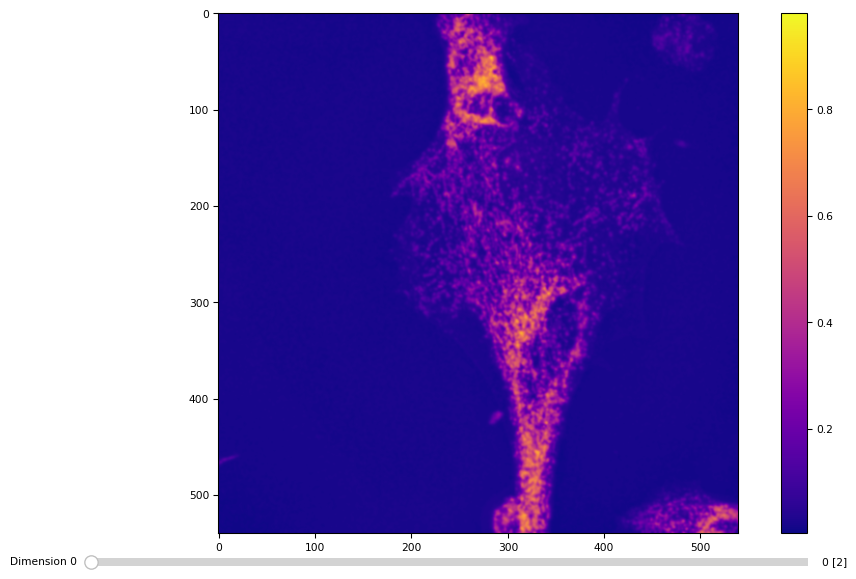

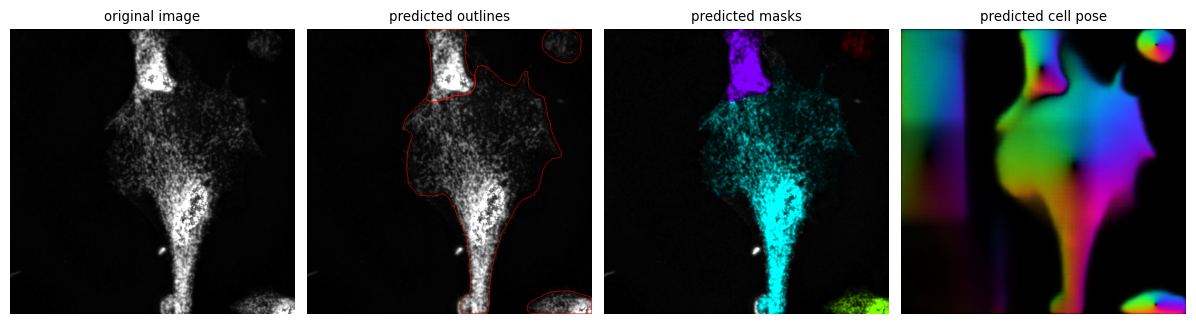

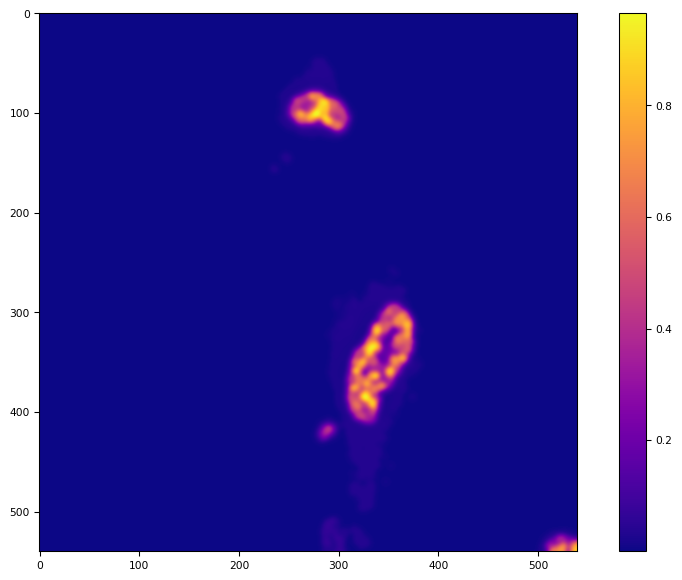

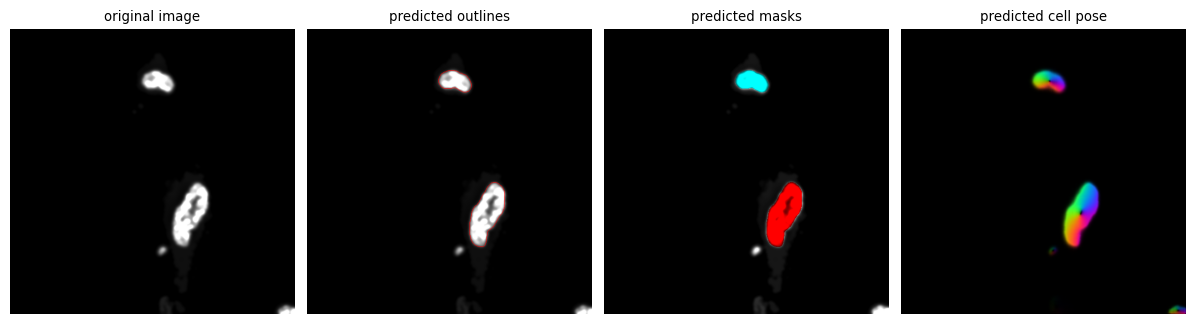

/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/Reworking_MitoSegmentation/MitoSegSubset/a_testmasks


In [82]:
img = img2_v3
pretrained_model = "cpdino"
model = load_model(pretrained_model=pretrained_model, gpu=True)
from skimage import feature, filters   
cell_masks = segment_cell_v3(img,model, show_image_preprocessing=True, diameter=None, cellprob_threshold=-0, flow_threshold=0.4)
nuc_masks = segment_nuclei_v3(
    img, model, nucleus_channel=3, show_image_preprocessing=True
)
# cell_v2_masks = segment_cell_v2(img2_v2,model)
# nuc_v2_masks = segment_nuclei_v2(img2_v2, model)

print(maskdir)

save_masks(set_name, cell_masks, outdir=maskdir, image_ext=image_ext, mask_type="cell_"+pretrained_model)
save_masks(
    set_name, nuc_masks, outdir=maskdir, image_ext=image_ext, mask_type="nuclei_"+pretrained_model
)


In [ ]:
def find_row_col_field_string(img_set_name):
    import re

    rowcol_pattern = r"r(\d{1,2})c(\d{1,2})f(\d{1,2})"  # Matches "RX" where X is the replicate number (placeholder for now)
    match = re.search(rowcol_pattern, img_set_name)
    if match:
        row_metadata = int(match.group(1))
        col_metadata = int(match.group(2))
        field_metadata = int(match.group(3))
        return f'r{str(row_metadata).rjust(2, "0")}c{str(col_metadata).rjust(2, "0")}f{str(field_metadata).rjust(2, "0")}'
    else:
        return ""

def process_segment_save_img(in_channels, selected_channels, maskdir, set_name, nucleus_channel=3, image_ext=".tif"):
    img_pre = img_preprocessing_hap1(in_channels, selected_channels)
    img = img_rescaled(img_pre, factor=0.25)
    cell_masks = segment_cell_hap1(
        img, model, selected_channels=selected_channels, nucleus_channel=nucleus_channel, show_plot=False
    )
    nuc_masks = segment_nuclei_v3(img, model, nucleus_channel=nucleus_channel, show_plot=False)
    print(maskdir)
    save_masks(set_name, cell_masks, outdir=maskdir, image_ext=image_ext, mask_type="cell")
    save_masks(set_name, nuc_masks, outdir=maskdir, image_ext=image_ext, mask_type="nuclei")
    
def load_mask_list(dir, image_ext=".tif"):
    """
    Sort the list of masks 
    Parameters:
          dir (Path object or str): the directory containing the images
          image_ext (str, optional): the image extension, tif by default
    Returns:
          files (list of Path objects): the list of files sorted by location and channel
    """
    if not dir.exists():
        raise FileNotFoundError("directory does not exist")
    try:
        files = [f for f in dir.glob("*" + image_ext) if "_masks" in f.name and "_flows" not in f.name and "SUM" not in f.name]
    except IndexError as e:
        print(f"{e}, empty list, returning []")
        return []
    if len(files) == 0:
        return []
    else:
        return files
    
def iterate_dirlist(dirlist, model, image_ext=".tif", skip_existing = True):
    for dir in dirlist:
        maskdir = Path.joinpath(dir,"testmasks")
        maskdir.mkdir(exist_ok=True)
        # get this list if I want to skip existing masks
        mask_files = load_mask_list(maskdir) 
        print(mask_files)
        if mask_files == []:
            continue
        #now get the file list
        files = load_sorted_directory_list(dir)
        grouped_files = group_files_by_channel(files)
        for image_set_index,file in enumerate(grouped_files):
            set_coords = find_row_col_field_string(file[0].name)
            print(set_coords)
            #skip files that were already processed
            if skip_existing and mask_files:
                if set_coords in [mfiles.name for mfiles in mask_files]:
                    continue
                else:
                    in_channels = load_image_set_hap1(grouped_files[image_set_index])
                    set_name = get_image_set_name(grouped_files[image_set_index])
                    process_segment_save_img(in_channels, selected_channels, maskdir, set_name)
            else:
                in_channels = load_image_set_hap1(grouped_files[image_set_index])
                set_name = get_image_set_name(grouped_files[image_set_index])
                process_segment_save_img(in_channels,selected_channels,maskdir, set_name)
           
            
iterate_dirlist(dirlist, model, image_ext=".tif")

In [ ]:
maskdir = dir / "testmasksss"
print(maskdir.exists())

### Cells to make modifications to the existning preprocessing code before running the model

In [ ]:
# img = io.imread(files[0])
img = img2
def segment_cell_tweaking(
    img,
    model,
    show_plot=True,
    flow_threshold=0.6,
    cellprob_threshold=-1,
    tile_norm_blocksize=100,
    diameter=60,
    min_size=500,
    max_size_frac=0.85,  # keep masks up to 70% of image size
    niter=1000,
):
    from skimage import filters, morphology, exposure

    gfp = img[:, :, 0]  # combine the ch1 and ch2 images to help cellpose out a bit
    rfp = img[:, :, 1]
    dapi = img[:, :, 2]  # save ch3 for later

    img_combo = gfp + rfp
    img_combo = img_01_normalization(img_combo)
    #tf.imshow(img_combo, cmap="viridis")
    # smooth image and improve outline (sigma is the gaussian kernel)
    img_combo = filters.gaussian(img_combo, sigma=1)
    #Can also use unsharp mask, but it tends to chop the outlines too short img_combo = filters.unsharp_mask(img_combo, radius=0.5, amount=2)

    # stack the images
    img_selected_channels = np.stack([img_combo, dapi], axis=-1)

    masks, flows, styles = model.eval(
        img_selected_channels,
        batch_size=64,
        niter=niter,
        diameter=diameter,
        flow_threshold=flow_threshold,
        cellprob_threshold=cellprob_threshold,
        normalize={"tile_norm_blocksize": tile_norm_blocksize},
        max_size_fraction=max_size_frac,
        min_size=min_size
    )
    masks = utils.fill_holes_and_remove_small_masks(masks, min_size=min_size)
    masks = utils.dilate_masks(masks, n_iter=2)
    print(utils.size_distribution(masks))
    # plot if true
    if show_plot:
        fig = plt.figure(figsize=(12, 5))
        plot.show_segmentation(fig, img_selected_channels, masks, flows[0])
        plt.tight_layout()
        plt.show()
    return masks


def segment_nuclei_tweaking(
    orig_img,
    model,
    show_plot=True,
    flow_threshold=0.5,
    cellprob_threshold=1,
    tile_norm_blocksize=100,
    min_size=400,
    max_size_frac=0.4,
    diameter=None,
    niter=None,
):
    from skimage import morphology, filters

    img = orig_img[:, :, 2]  # get the DAPI channel

    # remove speckle-shaped autofluor
    bg2 = morphology.white_tophat(img, morphology.disk(3))
    img = img - bg2
    img = morphology.closing(img, morphology.disk(2.5))
    
    # sharpen image and improve outline (radius is the gaussian kernel)
    img = img_01_normalization(img)
    img = filters.gaussian(img, sigma=2)
    #tf.imshow(img, cmap="plasma")
    #img = filters.unsharp_mask(img, radius=1, amount=2)
    masks, flows, styles = model.eval(
        img,
        batch_size=64,
        diameter=diameter,
        niter=niter,
        flow_threshold=flow_threshold,
        cellprob_threshold=cellprob_threshold,
        normalize={"tile_norm_blocksize": tile_norm_blocksize},
        max_size_fraction=max_size_frac,
    )
    # dilate before removing the ones touching edges to catch the stragglers
    masks = utils.dilate_masks(masks, n_iter=1)
    masks_removed_edges = utils.remove_edge_masks(masks)
    masks_removed_edges = utils.fill_holes_and_remove_small_masks(
        masks_removed_edges, min_size=min_size
    )

    if show_plot:
        fig = plt.figure(figsize=(12, 5))
        plot.show_segmentation(fig, img, masks_removed_edges, flows[0])
        plt.tight_layout()
        plt.show()
    return masks_removed_edges

cell_masks = segment_cell_tweaking(img,model)
cell_masks_2 = segment_cell_tweaking(img2_v2, model)
cell_masks_OG = segment_cell(img, model)
nuc_masks = segment_nuclei_tweaking(img, model)
nuc_masks_2 = segment_nuclei_tweaking(img2_v2, model)
# save_masks(set_name+"tweaking", cell_masks_2, outdir=maskdir, image_ext=image_ext)
# save_masks(set_name, nuc_masks, outdir=maskdir, image_ext=image_ext, mask_type="nuclei")


## Run Cellpose-SAM on folder of small images

if you have many large images, you may want to run them as a loop over images as above. 
    See `cellpose_functions` to run this
 moved to `save_mask_folder() `


### loop for all files in the group in the directory
```python
for i in trange(len(grouped_files)):
    file_group = grouped_files[i]
    img_set = load_image_set(file_group)
    img_set_name = get_image_set_name(file_group)
    print("Set name: ", set_name)
    
    stacked_img = img_preprocessing(img_set)
    rescaled_img = img_rescaled(stacked_img, factor=0.25)
    
    cell_masks = segment_cell(rescaled_img, show=False)
    nuc_masks = segment_nuclei(rescaled_img, show=False) 
    
    save_masks(img_set_name, cell_masks, image_ext=image_ext)
    save_masks(img_set_name, nuc_masks, image_ext=image_ext, mask_type="nuclei") 
```